# Gamma/Hadron Classification on the MAGIC Telescope Dataset

The MAGIC telescopes detect gamma rays from the ground. A gamma ray that hits the atmosphere starts a shower of particles. The shower emits Cherenkov light, which the telescope records as an image. Cosmic-ray hadrons start similar showers, so most recorded images are background. The task is to tell the two apart from features of the image.

This notebook compares six standard classifiers on this task.

**Dataset.** [MAGIC Gamma Telescope, UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/159/magic+gamma+telescope). It holds 19,020 simulated events with 10 continuous features and a binary label: `g` (gamma, signal) or `h` (hadron, background).

| Feature | Description |
|---|---|
| `fLength` | Major axis of the ellipse fitted to the image [mm] |
| `fWidth` | Minor axis of the ellipse [mm] |
| `fSize` | log10 of the sum of all pixel contents [photons] |
| `fConc` | Ratio of the two highest pixels to `fSize` |
| `fConc1` | Ratio of the highest pixel to `fSize` |
| `fAsym` | Distance from the highest pixel to the centre, projected on the major axis [mm] |
| `fM3Long` | Cube root of the third moment along the major axis [mm] |
| `fM3Trans` | Cube root of the third moment along the minor axis [mm] |
| `fAlpha` | Angle between the major axis and the vector to the origin [deg] |
| `fDist` | Distance from the origin to the centre of the ellipse [mm] |

## 1. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 0
DATA_PATH = Path("../data/magic_gamma_telescope.csv")
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid")

## 2. Load and inspect the data

In [2]:
df = pd.read_csv(DATA_PATH)
df = df.rename(columns={"fwidth": "fWidth"})  # match the naming of the other columns
print("Shape:", df.shape)
df.head()

Shape: (19020, 11)


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [3]:
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
df.describe().T

Missing values: 0
Duplicate rows: 115


,count,mean,std,min,25%,50%,75%,max
fLength,19020.0,53.250154,42.364855,4.2835,24.336000,37.14770,70.122175,334.1770
fWidth,19020.0,22.180966,18.346056,0.0000,11.863800,17.13990,24.739475,256.3820
fSize,19020.0,2.825017,0.472599,1.9413,2.477100,2.73960,3.101600,5.3233
fConc,19020.0,0.380327,0.182813,0.0131,0.235800,0.35415,0.503700,0.8930
fConc1,19020.0,0.214657,0.110511,0.0003,0.128475,0.19650,0.285225,0.6752
fAsym,19020.0,-4.331745,59.206062,-457.9161,-20.586550,4.01305,24.063700,575.2407
fM3Long,19020.0,10.545545,51.000118,-331.7800,-12.842775,15.31410,35.837800,238.3210
fM3Trans,19020.0,0.249726,20.827439,-205.8947,-10.849375,0.66620,10.946425,179.8510
fAlpha,19020.0,27.645707,26.103621,0.0000,5.547925,17.67950,45.883550,90.0000
fDist,19020.0,193.818026,74.731787,1.2826,142.492250,191.85145,240.563825,495.5610


There are no missing values. There are 115 duplicate rows out of 19,020. They are kept, because identical simulated events can occur and the number is small.

The label is converted to integers: gamma = 1 (signal), hadron = 0 (background).

In [4]:
df["class"] = df["class"].map({"g": 1, "h": 0})
FEATURES = df.columns.drop("class")
CLASS_NAMES = ["hadron", "gamma"]

df["class"].value_counts(normalize=True).rename(index=dict(enumerate(CLASS_NAMES))).round(3)

class
gamma     0.648
hadron    0.352
Name: proportion, dtype: float64

The classes are imbalanced: about 65% gamma and 35% hadron. A model that always predicts gamma already reaches 65% accuracy. This is the baseline to beat.

## 3. Exploratory analysis

### Feature distributions by class

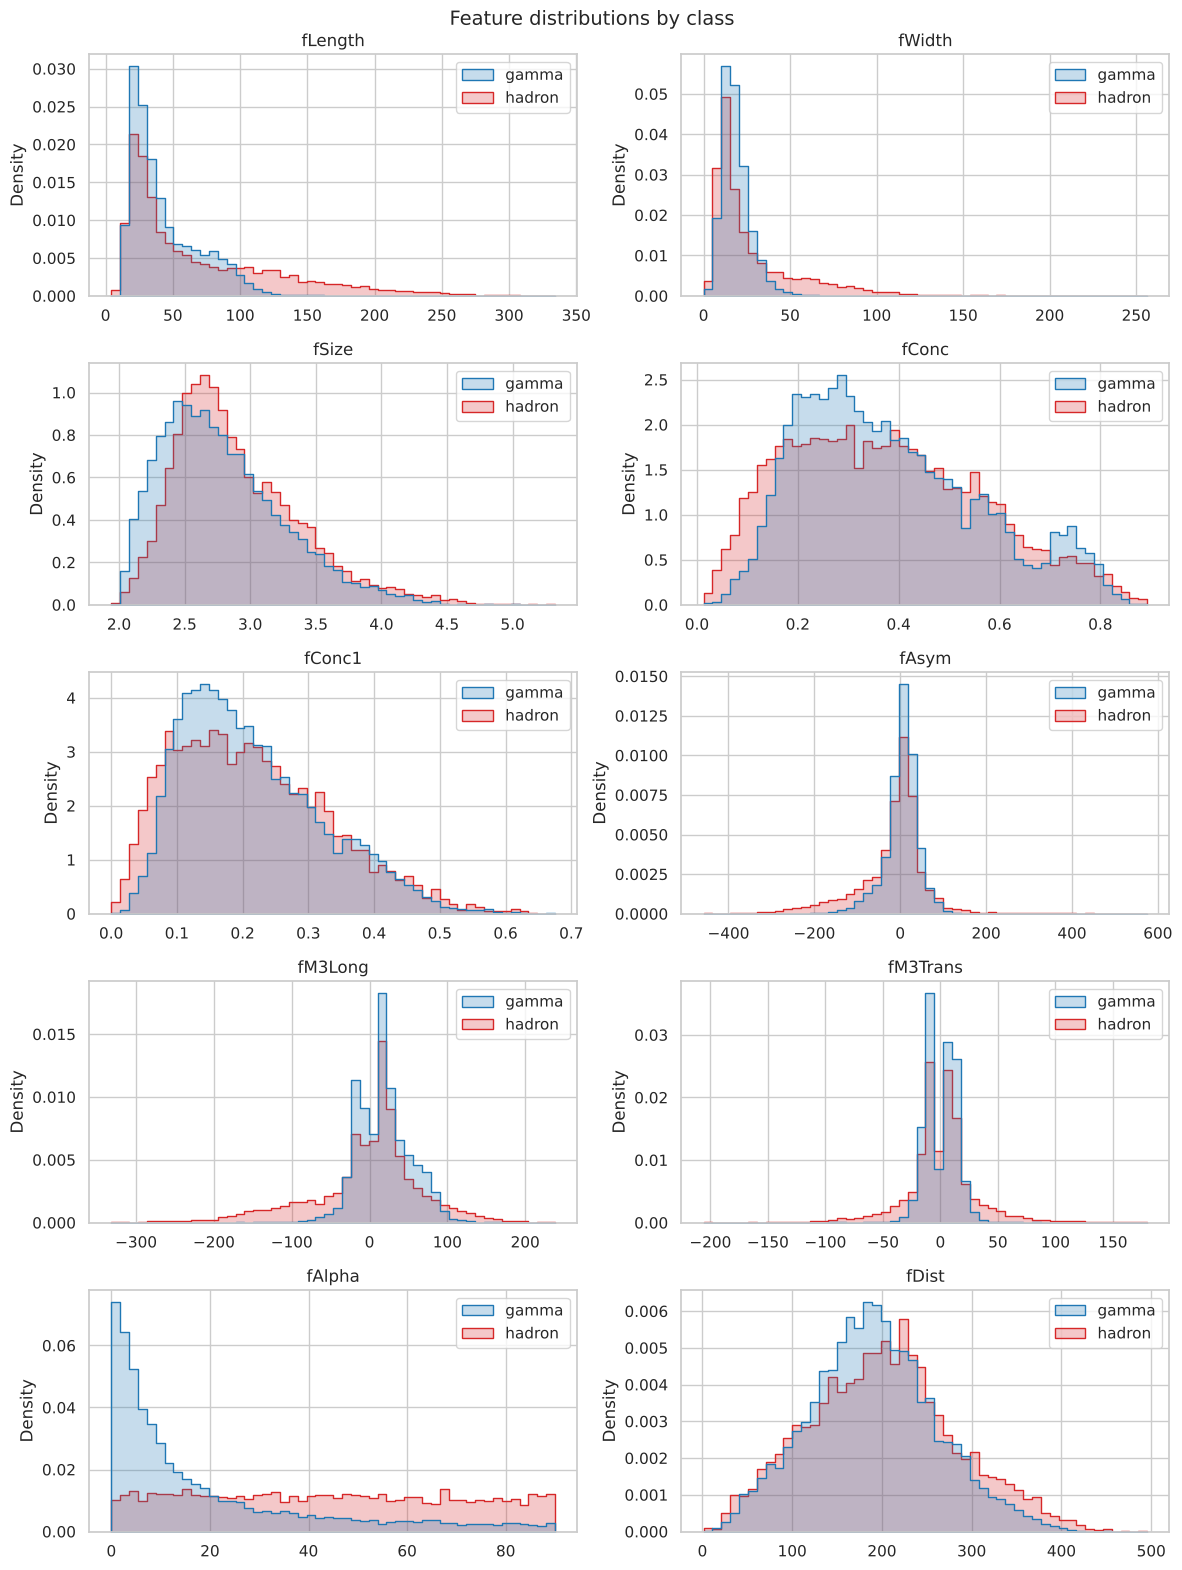

In [5]:
plot_df = df.assign(label=df["class"].map(dict(enumerate(CLASS_NAMES))))

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 16))
for ax, col in zip(axes.flat, FEATURES):
    sns.histplot(
        data=plot_df, x=col, hue="label", stat="density", common_norm=False,
        element="step", bins=50, ax=ax, palette={"hadron": "tab:red", "gamma": "tab:blue"},
    )
    ax.get_legend().set_title(None)
    ax.set_title(col)
    ax.set_xlabel("")
fig.suptitle("Feature distributions by class", fontsize=14)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "feature_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

`fAlpha` separates the classes best. Gamma showers point towards the source, so their `fAlpha` is concentrated near 0. Hadron showers arrive from random directions, so their `fAlpha` is spread out. `fLength` and `fWidth` also differ: hadron images tend to be larger.

### Correlation between features

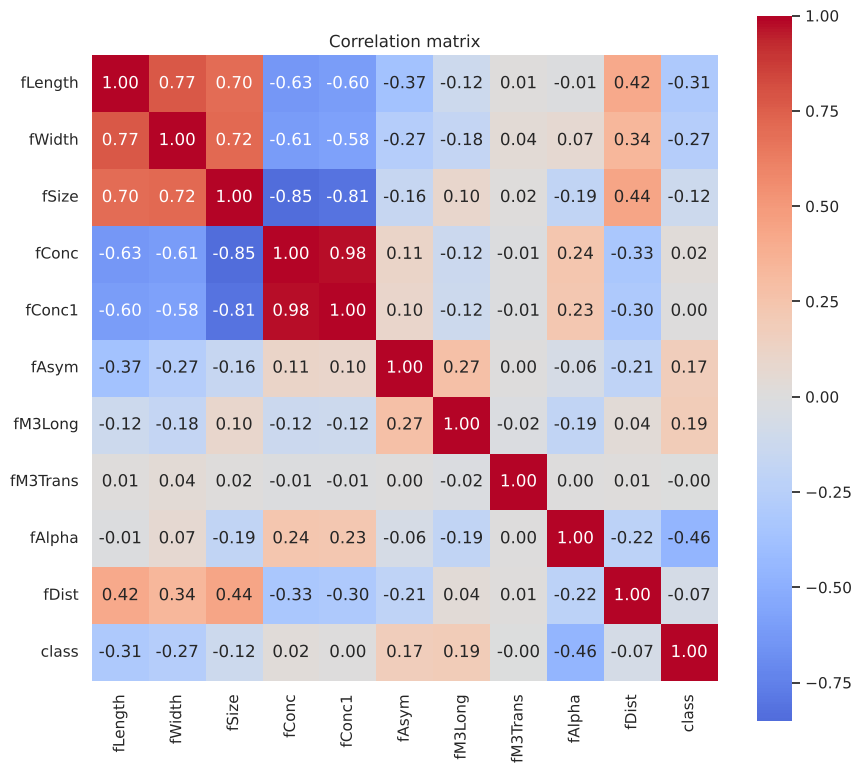

In [6]:
fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=ax)
ax.set_title("Correlation matrix")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "correlation_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

`fConc` and `fConc1` are almost perfectly correlated (0.98). `fSize` is strongly correlated with both. `fAlpha` has the strongest correlation with the label. All features are kept, since none of the models below suffer much from a few correlated inputs.

## 4. Train/test split

25% of the data is held out for testing. The split is stratified, so both sets keep the same class ratio.

In [7]:
X = df[FEATURES]
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (14265, 10)  Test: (4755, 10)


## 5. Models

Each model is wrapped in a pipeline with a `StandardScaler`. The scaler is then fitted on the training data only, which avoids leaking test information into training. The same pipeline is reused later for predictions on new events.

Tree-based models do not need scaling. The scaler is kept for them anyway, so that all models share the same interface.

In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "K-Nearest Neighbours": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    "SVM (RBF kernel)": SVC(),
}
pipelines = {name: make_pipeline(StandardScaler(), model) for name, model in models.items()}

Each model is evaluated with:

- **5-fold cross-validated accuracy** on the training set, to get a more stable estimate than a single split.
- **Train and test accuracy**, to detect overfitting.
- **ROC AUC** on the test set. Accuracy depends on one decision threshold. The UCI description notes that accuracy alone is not a good measure here, because a hadron wrongly accepted as gamma is more costly than the reverse. ROC AUC summarises performance over all thresholds.

In [9]:
def positive_class_scores(pipe, X):
    # Score that increases with the likelihood of the gamma class.
    if hasattr(pipe, "predict_proba"):
        return pipe.predict_proba(X)[:, 1]
    return pipe.decision_function(X)  # SVC has no probabilities by default


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []

for name, pipe in pipelines.items():
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
    pipe.fit(X_train, y_train)
    rows.append({
        "Model": name,
        "CV accuracy": cv_scores.mean(),
        "CV std": cv_scores.std(),
        "Train accuracy": accuracy_score(y_train, pipe.predict(X_train)),
        "Test accuracy": accuracy_score(y_test, pipe.predict(X_test)),
        "Test ROC AUC": roc_auc_score(y_test, positive_class_scores(pipe, X_test)),
    })

results = pd.DataFrame(rows).set_index("Model").sort_values("Test ROC AUC", ascending=False)
results.round(3)

,CV accuracy,CV std,Train accuracy,Test accuracy,Test ROC AUC
Model,,,,,
Random Forest,0.877,0.003,1.000,0.880,0.933
SVM (RBF kernel),0.867,0.003,0.872,0.872,0.916
K-Nearest Neighbours,0.834,0.003,0.881,0.836,0.878
Logistic Regression,0.790,0.006,0.790,0.792,0.847
Decision Tree,0.818,0.008,1.000,0.811,0.791
Naive Bayes,0.726,0.007,0.726,0.733,0.772


## 6. Comparison

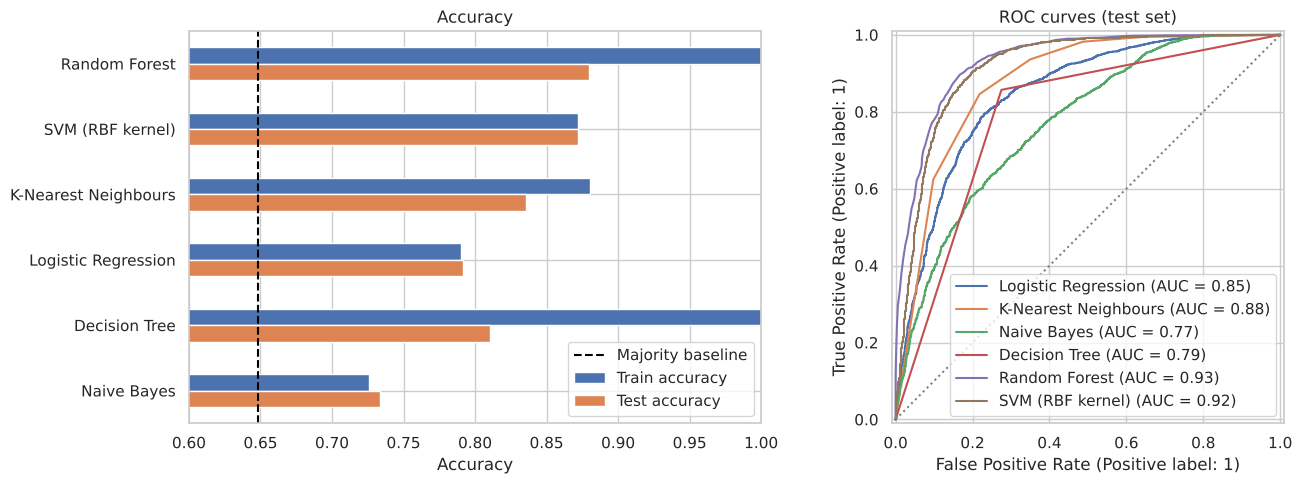

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results[["Train accuracy", "Test accuracy"]].plot.barh(ax=axes[0])
axes[0].axvline(y.mean(), color="black", linestyle="--", label="Majority baseline")
axes[0].set_xlim(0.6, 1.0)
axes[0].set_xlabel("Accuracy")
axes[0].set_ylabel("")
axes[0].invert_yaxis()
axes[0].legend(loc="lower right")
axes[0].set_title("Accuracy")

for name, pipe in pipelines.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, name=name, ax=axes[1])
axes[1].plot([0, 1], [0, 1], color="grey", linestyle=":")
axes[1].set_title("ROC curves (test set)")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

Observations:

- All models beat the 65% majority baseline.
- Random Forest and SVM perform best, with test accuracy around 87–88%.
- Decision Tree and Random Forest reach close to 100% training accuracy. The gap to their test accuracy shows that they memorise the training set. For the single Decision Tree, this costs a lot of test performance. Random Forest averages many trees, so it still generalises well.
- Naive Bayes is the weakest model. It assumes the features are independent, but several of them are strongly correlated.
- The cross-validated accuracy is close to the test accuracy for every model. The test results are therefore not an artefact of one lucky split.

## 7. Best model in detail

In [11]:
best_name = results.index[0]
best_model = pipelines[best_name]
print("Best model by ROC AUC:", best_name)
print()
print(classification_report(y_test, best_model.predict(X_test), target_names=CLASS_NAMES, digits=3))

Best model by ROC AUC: Random Forest

              precision    recall  f1-score   support

      hadron      0.869     0.775     0.819      1672
       gamma      0.885     0.937     0.910      3083

    accuracy                          0.880      4755
   macro avg      0.877     0.856     0.864      4755
weighted avg      0.879     0.880     0.878      4755



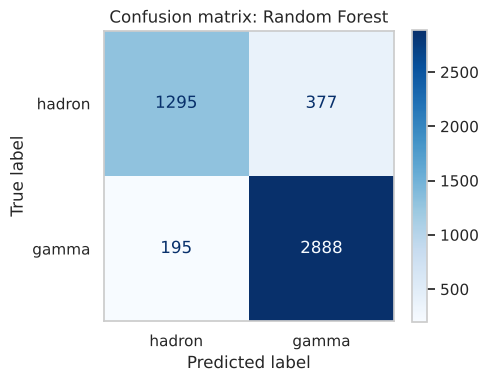

In [12]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test, display_labels=CLASS_NAMES, cmap="Blues", ax=ax
)
ax.set_title(f"Confusion matrix: {best_name}")
ax.grid(False)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

Recall is higher for gamma than for hadron. The model is better at finding gamma events than at rejecting hadrons. This is partly because gamma events are the majority class.

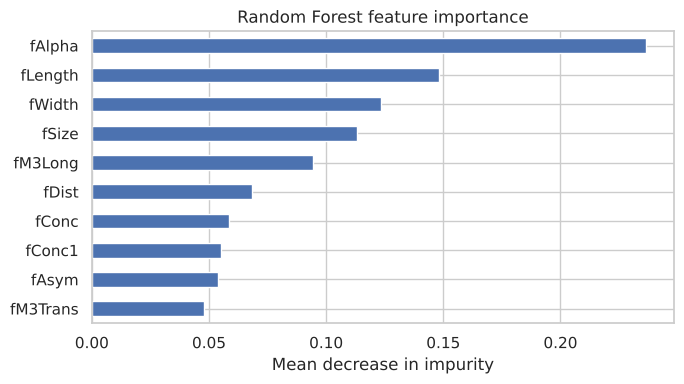

In [13]:
importances = pd.Series(
    pipelines["Random Forest"][-1].feature_importances_, index=FEATURES
).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot.barh(ax=ax)
ax.set_xlabel("Mean decrease in impurity")
ax.set_title("Random Forest feature importance")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

`fAlpha` is the most important feature, followed by `fLength`. This agrees with the distribution plots in Section 3.

## 8. Predicting a new event

The fitted pipeline includes the scaler, so a raw event can be passed in directly.

In [14]:
new_event = pd.DataFrame(
    [[31.6036, 11.7235, 2.5185, 0.5303, 0.3773, 26.2722, 23.8238, -9.9574, 6.3609, 205.261]],
    columns=FEATURES,
)
prediction = best_model.predict(new_event)[0]
print("Prediction:", "gamma (signal)" if prediction == 1 else "hadron (background)")

Prediction: gamma (signal)


## 9. Conclusion

Six classifiers were compared on the MAGIC gamma/hadron dataset. Random Forest gave the best results, with 88% test accuracy and a ROC AUC of 0.93. SVM came close behind. The most useful feature is `fAlpha`, the orientation of the shower image.

Possible next steps:

- Tune hyperparameters with a grid or random search.
- Try gradient-boosted trees, such as `HistGradientBoostingClassifier`.
- Choose the decision threshold for a fixed, low hadron acceptance rate. This matches how the classifier would be used in a real gamma-ray analysis.